In [1]:
import h5py
import torch
import glob
import sys
import pickle
import numpy as np
import os
sys.path.append('../')

import src.audio_transforms as at
from pathlib import Path

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/torchaudio/_internal/module_utils.py:99: UserWarning: Failed to import soundfile. 'soundfile' backend is not available.
  warnings.warn("Failed to import soundfile. 'soundfile' backend is not available.")


In [3]:
root = '/om2/user/msaddler/projects/ibmHearingAid/assets/data/datasets/JSIN_v3.00/nStim_20000/' \
        '2000ms/rms_0.1/noiseSNR_-10_10/stimSR_20000/reverb_none/noise_all/JSIN_all_v3/subsets/' # Path to raw GigaSpeech dataset


In [5]:
hdf5_glob = 'JSIN_all__run_*.h5'

In [9]:
h5_file = glob.glob(root + '/valid_*/' + hdf5_glob)[0]

In [11]:
h5_file

'/om2/user/msaddler/projects/ibmHearingAid/assets/data/datasets/JSIN_v3.00/nStim_20000/2000ms/rms_0.1/noiseSNR_-10_10/stimSR_20000/reverb_none/noise_all/JSIN_all_v3/subsets/valid_RQTTZB4C3TJJVLJUWDV72TYMC7S4MNHH/JSIN_all__run_000_RQTTZB4C3TJJVLJUWDV72TYMC7S4MNHH.h5'

In [12]:
dataset = h5py.File(h5_file, 'r', swmr=True)

In [14]:
# set handles for access         
speakers = dataset['sources']['signal']['speaker_int']
signals = dataset['sources']['signal']['signal'] 
noises = dataset['sources']['noise']['signal']


In [27]:
## Path to HRTFs 

c = '/om/user/francl/Room_Simulator_20181115_Rebuild/' \
        'Expanded_HRIRdist140-5deg_elev_az_room10x10y4z_materials11wall22floor20ciel/'

hrtf_paths = glob.glob(hrtf_dir + 'Expanded_HRIRdist140-5deg_elev_az_room10x10y4z_materials11wall22floor20ciel/*')

In [32]:
locations = np.unique([loc[:-6] for loc in os.listdir(hrtf_dir)])

In [36]:
locations

array(['-10elev_0az_1.40x1.40y2.00z', '-10elev_0az_1.40x2.40y2.00z',
       '-10elev_0az_1.40x3.40y2.00z', ..., '90elev_95az_8.60x6.60y2.00z',
       '90elev_95az_8.60x7.60y2.00z', '90elev_95az_8.60x8.60y2.00z'],
      dtype='<U29')

In [41]:
location = locations[10]
left_str = '_l.wav'
left = Path(hrtf_dir, location + '_l.wav')

In [42]:
left

PosixPath('/om/user/francl/Room_Simulator_20181115_Rebuild/Expanded_HRIRdist140-5deg_elev_az_room10x10y4z_materials11wall22floor20ciel/-10elev_0az_2.40x3.40y2.00z_l.wav')

In [46]:
DEFAULT_OFFSET = 201
import math

def _get_log_freq(sample_rate, max_sweep_rate, offset):
    """Get freqs evenly spaced out in log-scale, between [0, max_sweep_rate // 2]

    offset is used to avoid negative infinity `log(offset + x)`.

    """
    start, stop = math.log(offset), math.log(offset + max_sweep_rate // 2)
    return torch.exp(torch.linspace(start, stop, sample_rate, dtype=torch.double)) - offset


def _get_inverse_log_freq(freq, sample_rate, offset):
    """Find the time where the given frequency is given by _get_log_freq"""
    half = sample_rate // 2
    return sample_rate * (math.log(1 + freq / offset) / math.log(1 + half / offset))


def _get_freq_ticks(sample_rate, offset, f_max):
    # Given the original sample rate used for generating the sweep,
    # find the x-axis value where the log-scale major frequency values fall in
    time, freq = [], []
    for exp in range(2, 5):
        for v in range(1, 10):
            f = v * 10**exp
            if f < sample_rate // 2:
                t = _get_inverse_log_freq(f, sample_rate, offset) / sample_rate
                time.append(t)
                freq.append(f)
    t_max = _get_inverse_log_freq(f_max, sample_rate, offset) / sample_rate
    time.append(t_max)
    freq.append(f_max)
    return time, freq


def get_sine_sweep(sample_rate, offset=DEFAULT_OFFSET):
    max_sweep_rate = sample_rate
    freq = _get_log_freq(sample_rate, max_sweep_rate, offset)
    delta = 2 * math.pi * freq / sample_rate
    cummulative = torch.cumsum(delta, dim=0)
    signal = torch.sin(cummulative).unsqueeze(dim=0)
    return signal

In [50]:
%matplotlib inline

import matplotlib.pyplot as plt

In [63]:
def plot_sweep(
    waveform,
    sample_rate,
    title,
    max_sweep_rate=48000,
    offset=DEFAULT_OFFSET,
):
    x_ticks = [100, 500, 1000, 5000, 10000, 20000, max_sweep_rate // 2]
    y_ticks = [1000, 5000, 10000, 20000, sample_rate // 2]

    time, freq = _get_freq_ticks(max_sweep_rate, offset, sample_rate // 2)
    freq_x = [f if f in x_ticks and f <= max_sweep_rate // 2 else None for f in freq]
    freq_y = [f for f in freq if f in y_ticks and 1000 <= f <= sample_rate // 2]

    figure, axis = plt.subplots(1, 1)
    _, _, _, cax = axis.specgram(waveform[0].numpy(), Fs=sample_rate)
    plt.xticks(time, freq_x)
    plt.yticks(freq_y, freq_y)
    axis.set_xlabel("Original Signal Frequency (Hz, log scale)")
    axis.set_ylabel("Waveform Frequency (Hz)")
    axis.xaxis.grid(True, alpha=0.67)
    axis.yaxis.grid(True, alpha=0.67)
    figure.suptitle(f"{title} (sample rate: {sample_rate} Hz)")
    plt.colorbar(cax)
    plt.show(block=True)

In [64]:
sample_rate = 48000
waveform = get_sine_sweep(sample_rate)

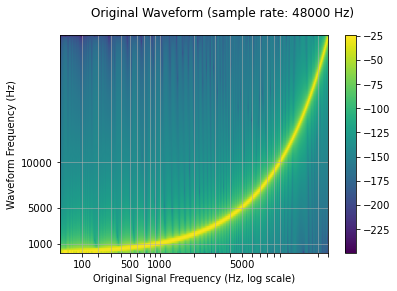

In [65]:
plot_sweep(waveform, sample_rate, title="Original Waveform")
